In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [23]:
df = pd.read_csv(r"D:\2026\Customer-Churn-Intelligence-System\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)

df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicated Rows:", df.duplicated().sum())

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID      

In [25]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [26]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [27]:
df.head()
df.dtypes
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Data Cleaning

In [28]:
data = df.copy()

# Convert TotalCharges from object to numeric
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Check missing values after conversion
missing_after_conversion = data.isnull().sum()
missing_after_conversion[missing_after_conversion > 0]

TotalCharges    11
dtype: int64

In [29]:
# Drop rows with missing TotalCharges
data = data.dropna(subset=["TotalCharges"])
print("Shape after cleaning:", data.shape)
print("Missing values:", data.isnull().sum().sum())

Shape after cleaning: (7032, 21)
Missing values: 0


In [30]:
# Convert Churn target to numeric
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

# Drop customerID because it is only an identifier
data = data.drop(columns=["customerID"])

data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [31]:
#Quick Clean Data Check
print("Final cleaned shape:", data.shape)
print("\nData types:")
print(data.dtypes)

print("\nChurn distribution:")
print(data["Churn"].value_counts())

print("\nChurn percentage:")
print(data["Churn"].value_counts(normalize=True) * 100)

Final cleaned shape: (7032, 20)

Data types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn percentage:
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


Simple Feature Engineering

In [32]:
# Tenure groups
def tenure_group(tenure):
    if tenure <= 12:
        return "0-1 Year"
    elif tenure <= 24:
        return "1-2 Years"
    elif tenure <= 48:
        return "2-4 Years"
    else:
        return "4+ Years"

data["TenureGroup"] = data["tenure"].apply(tenure_group)


# Monthly charges groups
def monthly_charge_group(charge):
    if charge < 35:
        return "Low"
    elif charge < 70:
        return "Medium"
    else:
        return "High"

data["MonthlyChargeGroup"] = data["MonthlyCharges"].apply(monthly_charge_group)


# Contract risk indicator
data["MonthToMonthRisk"] = data["Contract"].apply(
    lambda x: 1 if x == "Month-to-month" else 0
)

data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,MonthlyChargeGroup,MonthToMonthRisk
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1 Year,Low,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,2-4 Years,Medium,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1 Year,Medium,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4 Years,Medium,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1 Year,High,1


EDA

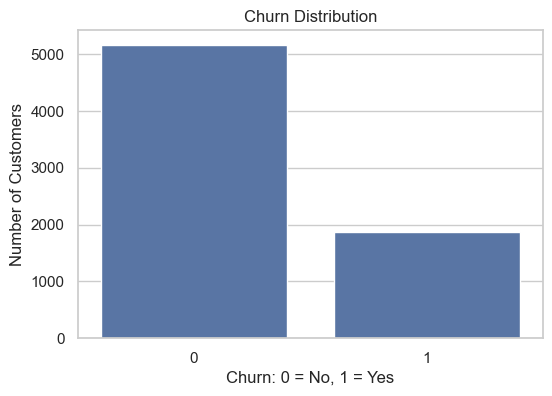

In [33]:
#Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn: 0 = No, 1 = Yes")
plt.ylabel("Number of Customers")
plt.show()

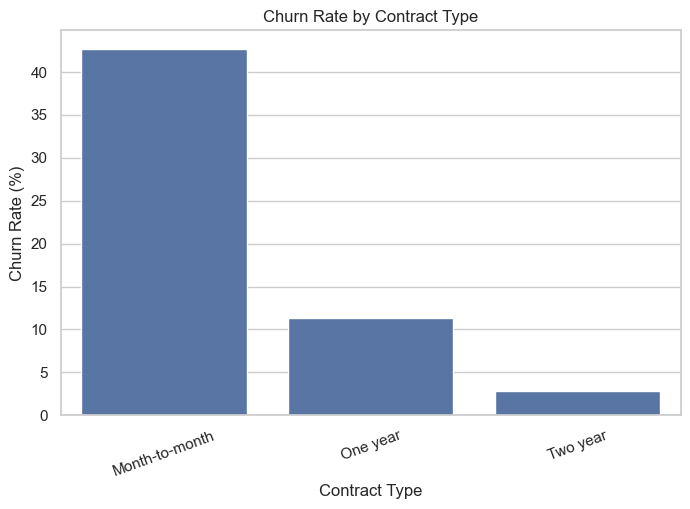

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

In [34]:
#Churn Rate by Contract
contract_churn = data.groupby("Contract")["Churn"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=contract_churn.index, y=contract_churn.values)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

contract_churn

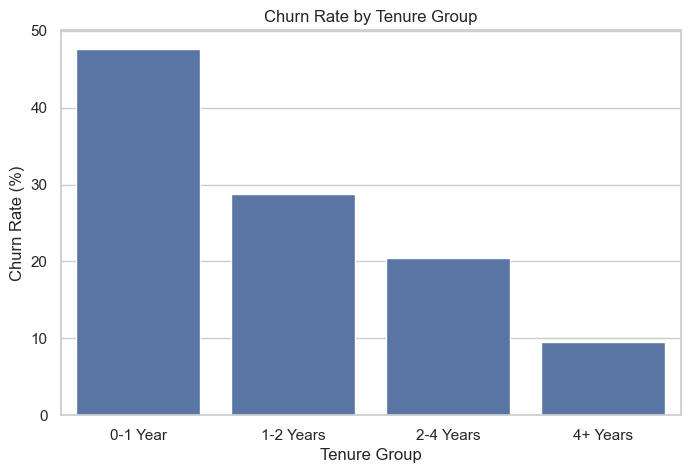

TenureGroup
0-1 Year     47.678161
1-2 Years    28.710938
2-4 Years    20.388959
4+ Years      9.513176
Name: Churn, dtype: float64

In [35]:
# Churn Rate by Tenure Group
tenure_churn = data.groupby("TenureGroup")["Churn"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=tenure_churn.index, y=tenure_churn.values)
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.show()

tenure_churn

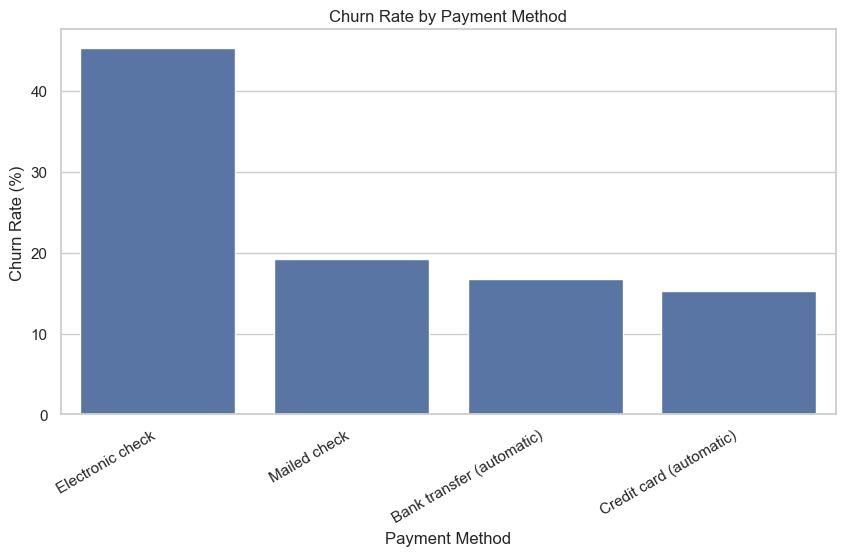

PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn, dtype: float64

In [36]:
# Churn Rate by Payment Method
payment_churn = data.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=payment_churn.index, y=payment_churn.values)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

payment_churn

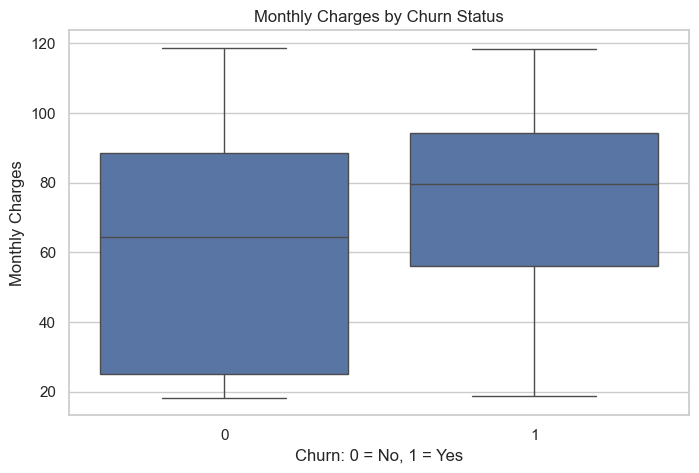

In [37]:
# Monthly Charges by Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn: 0 = No, 1 = Yes")
plt.ylabel("Monthly Charges")
plt.show()

In [38]:
overall_churn_rate = data["Churn"].mean() * 100

highest_contract = contract_churn.idxmax()
highest_contract_rate = contract_churn.max()

highest_tenure = tenure_churn.idxmax()
highest_tenure_rate = tenure_churn.max()

highest_payment = payment_churn.idxmax()
highest_payment_rate = payment_churn.max()

print("Business Insights")
print("=" * 60)

print(f"1. Overall churn rate is {overall_churn_rate:.2f}%.")
print(f"2. Customers with {highest_contract} contracts have the highest churn rate: {highest_contract_rate:.2f}%.")
print(f"3. Customers in the {highest_tenure} tenure group have the highest churn rate: {highest_tenure_rate:.2f}%.")
print(f"4. Customers using {highest_payment} have the highest churn rate: {highest_payment_rate:.2f}%.")
print("5. Customers with higher monthly charges appear more likely to churn.")

Business Insights
1. Overall churn rate is 26.58%.
2. Customers with Month-to-month contracts have the highest churn rate: 42.71%.
3. Customers in the 0-1 Year tenure group have the highest churn rate: 47.68%.
4. Customers using Electronic check have the highest churn rate: 45.29%.
5. Customers with higher monthly charges appear more likely to churn.


**Modeling**

In [39]:
# Separate features and target

X = data.drop(columns=["Churn"])
y = data["Churn"]

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumeric Features:")
print(numeric_features)

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup', 'MonthlyChargeGroup']

Numeric Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'MonthToMonthRisk']


In [40]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (5625, 22)
Testing set: (1407, 22)

Train target distribution:
Churn
0    73.422222
1    26.577778
Name: proportion, dtype: float64

Test target distribution:
Churn
0    73.418621
1    26.581379
Name: proportion, dtype: float64


In [41]:
#Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Compatible OneHotEncoder for different sklearn versions
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", encoder, categorical_features)
    ]
)

print("Preprocessing pipeline is ready.")

Preprocessing pipeline is ready.


Train Logistic Regression Model

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Train Random Forest Model

In [43]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [44]:
#Evaluate Models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }
    
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return results

Compare Models

In [45]:
logistic_results = evaluate_model(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression"
)

rf_results = evaluate_model(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest"
)

results_df = pd.DataFrame([logistic_results, rf_results])
results_df

Logistic Regression
Confusion Matrix:
[[719 314]
 [ 78 296]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407

Random Forest
Confusion Matrix:
[[834 199]
 [127 247]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1033
           1       0.55      0.66      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.77      1407



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.721393,0.485246,0.791444,0.601626,0.834311
1,Random Forest,0.768301,0.553812,0.660428,0.602439,0.814681


In [46]:
# Save Model Results
results_df.to_csv("model_results.csv", index=False)
print("Model results saved successfully.")

Model results saved successfully.


Choose Best Model Based on Recall

In [47]:
best_model_name = results_df.sort_values(by="Recall", ascending=False).iloc[0]["Model"]

if best_model_name == "Logistic Regression":
    best_model = logistic_model
else:
    best_model = random_forest_model

print("Best model based on Recall:", best_model_name)

Best model based on Recall: Logistic Regression


In [48]:
# Save Best Model
import joblib
from pathlib import Path

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(best_model, MODELS_DIR / "best_churn_model.pkl")

print("Best model saved successfully.")

Best model saved successfully.


Feature Importance

In [49]:
# Get feature names after preprocessing

feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
trained_model = best_model.named_steps["model"]

if hasattr(trained_model, "feature_importances_"):
    importance_values = trained_model.feature_importances_
else:
    importance_values = abs(trained_model.coef_[0])

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
1,num__tenure,1.127683
17,cat__InternetService_Fiber optic,0.667764
16,cat__InternetService_DSL,0.578647
39,cat__Contract_Two year,0.534970
2,num__MonthlyCharges,0.528395
4,num__MonthToMonthRisk,0.460835
47,cat__TenureGroup_1-2 Years,0.388258
49,cat__TenureGroup_4+ Years,0.360051
3,num__TotalCharges,0.313073
33,cat__StreamingTV_Yes,0.268573


Plot Top Important Features

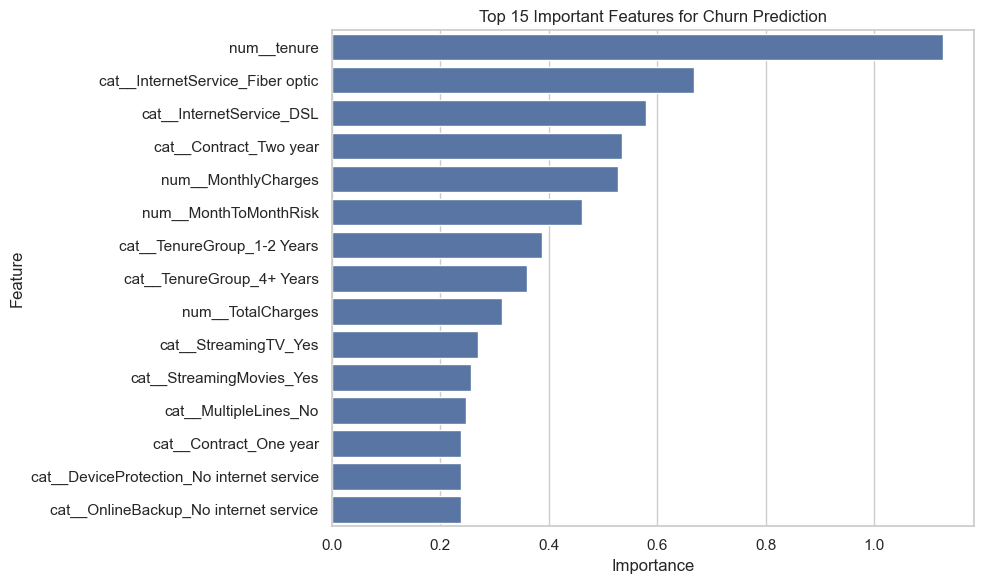

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features for Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Save Feature Importance

In [51]:
feature_importance.to_csv("feature_importance.csv", index=False)
print("Feature importance saved successfully.")

Feature importance saved successfully.


Predict Churn Risk for Sample Customers

In [52]:
sample_customers = X_test.head(10).copy()

sample_customers["Churn_Probability"] = best_model.predict_proba(X_test.head(10))[:, 1]
sample_customers["Predicted_Churn"] = best_model.predict(X_test.head(10))

def risk_level(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

sample_customers["Risk_Level"] = sample_customers["Churn_Probability"].apply(risk_level)

sample_customers[["Churn_Probability", "Predicted_Churn", "Risk_Level"]]

,Churn_Probability,Predicted_Churn,Risk_Level
974,0.059382,0,Low Risk
619,0.814989,1,High Risk
4289,0.020218,0,Low Risk
3721,0.413302,0,Medium Risk
4533,0.216759,0,Low Risk
445,0.749229,1,High Risk
5898,0.071521,0,Low Risk
3387,0.362630,0,Low Risk
1346,0.813972,1,High Risk
5690,0.059987,0,Low Risk


In [53]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.721393,0.485246,0.791444,0.601626,0.834311
1,Random Forest,0.768301,0.553812,0.660428,0.602439,0.814681


In [54]:
feature_importance.head(10)

,Feature,Importance
1,num__tenure,1.127683
17,cat__InternetService_Fiber optic,0.667764
16,cat__InternetService_DSL,0.578647
39,cat__Contract_Two year,0.534970
2,num__MonthlyCharges,0.528395
4,num__MonthToMonthRisk,0.460835
47,cat__TenureGroup_1-2 Years,0.388258
49,cat__TenureGroup_4+ Years,0.360051
3,num__TotalCharges,0.313073
33,cat__StreamingTV_Yes,0.268573


In [55]:
# Logistic Regression Coefficient Importance

feature_names = logistic_model.named_steps["preprocess"].get_feature_names_out()
coefficients = logistic_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Coefficient": abs(coefficients)
}).sort_values(by="Abs_Coefficient", ascending=False)

coef_df.head(15)

,Feature,Coefficient,Abs_Coefficient
1,num__tenure,-1.127683,1.127683
17,cat__InternetService_Fiber optic,0.667764,0.667764
16,cat__InternetService_DSL,-0.578647,0.578647
39,cat__Contract_Two year,-0.534970,0.534970
2,num__MonthlyCharges,-0.528395,0.528395
4,num__MonthToMonthRisk,0.460835,0.460835
47,cat__TenureGroup_1-2 Years,-0.388258,0.388258
49,cat__TenureGroup_4+ Years,0.360051,0.360051
3,num__TotalCharges,0.313073,0.313073
33,cat__StreamingTV_Yes,0.268573,0.268573


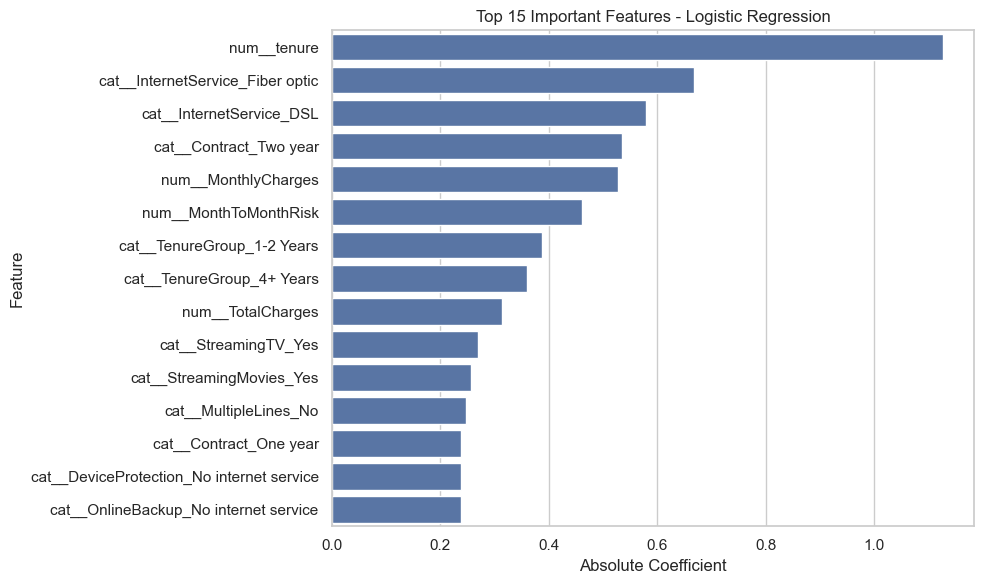

Feature importance saved.


In [57]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df.head(15),
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Top 15 Important Features - Logistic Regression")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
coef_df.to_csv("feature_importance.csv", index=False)
print("Feature importance saved.")

### Model Selection Insight

Although Random Forest achieved higher overall accuracy, Logistic Regression achieved better Recall and ROC-AUC.  
In churn prediction, Recall is especially important because the business wants to identify as many potential churn customers as possible before they leave.

Therefore, Logistic Regression was selected as the best model for this project.